In [44]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks")
from multiclass_fuctions1 import * # all
# from multiclass_functions1_8 import * # all
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cpu


In [46]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss()
new_model_train = True
model_type = "MLP"
dataset = "MNIST"
save_model_path = f"/content/drive/MyDrive/Colab Notebooks/results/{model_type}_{dataset}.pt"

In [47]:
transform = transforms.ToTensor()
train_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=True, download=True, transform=transform)
test_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform)
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [48]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Sequential(nn.Linear(28*28, 100),
                                    nn.ReLU(),
                                    nn.Linear(100,10))

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.linear(x)
        return x




In [49]:
exec(f"model = {model_type}().to(DEVICE)")
print(model)
x_batch, _ = next(iter(train_DL))
print(model(x_batch.to(DEVICE)).shape)

MLP(
  (linear): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)
torch.Size([32, 10])


In [35]:
# def Train(model, train_DL, criterion, optimizer):

#     loss_history =[]
#     NoT = len(train_DL.dataset)

#     model.train() # train mode로 전환
#     for ep in range(EPOCH):
#         rloss = 0 # running loss
#         for x_batch, y_batch in train_DL:
#             x_batch = x_batch.to(DEVICE)
#             y_batch = y_batch.to(DEVICE)
#             # inference
#             y_hat = model(x_batch)
#             # loss
#             loss = criterion(y_hat, y_batch)
#             # update
#             optimizer.zero_grad() # gradient 누적을 막기 위한 초기화
#             loss.backward() # backpropagation
#             optimizer.step() # weight update
#             # loss accumulation
#             loss_b = loss.item() * x_batch.shape[0] # batch loss # BATCH_SIZE를 곱하면 마지막 18개도 32개를 곱하니까..
#             rloss += loss_b # running loss
#         # print loss
#         loss_e = rloss/NoT
#         loss_history += [loss_e]
#         print(f"Epoch: {ep+1}, train loss: {round(loss_e,3)}")
#         print("-"*20)

#     return loss_history

# def Test(model, test_DL):
#     model.eval()
#     with torch.no_grad():
#         rcorrect = 0
#         for x_batch, y_batch in test_DL:
#             x_batch = x_batch.to(DEVICE)
#             y_batch = y_batch.to(DEVICE)
#             # inference
#             y_hat = model(x_batch)
#             # accuracy accumulation
#             pred = y_hat.argmax(dim=1)
#             corrects_b = torch.sum(pred == y_batch).item()
#             rcorrect += corrects_b
#         accuracy_e = rcorrect/len(test_DL.dataset)*100
#     print(f"Test accuracy: {rcorrect}/{len(test_DL.dataset)} ({round(accuracy_e,1)} %)")


# def Test_plot(model, test_DL):
#     model.eval()
#     with torch.no_grad():
#         x_batch, y_batch = next(iter(test_DL))
#         x_batch = x_batch.to(DEVICE)
#         y_hat = model(x_batch)
#         pred = y_hat.argmax(dim=1)

#     x_batch = x_batch.to("cpu")

#     plt.figure(figsize=(8,4))
#     for idx in range(6):
#         plt.subplot(2,3, idx+1, xticks=[], yticks=[])
#         plt.imshow(x_batch[idx].permute(1,2,0).squeeze(), cmap="gray")
#         pred_class = test_DL.dataset.classes[pred[idx]]
#         true_class = test_DL.dataset.classes[y_batch[idx]]
#         plt.title(f"{pred_class} ({true_class})", color = "g" if pred_class==true_class else "r")

# # 파라미터 수 구하기
# def count_params(model):
#     num = sum([p.numel() for p in model.parameters() if p.requires_grad])
#     return num


Epoch: 1, train loss: 0.301
--------------------
Epoch: 2, train loss: 0.135
--------------------
Epoch: 3, train loss: 0.095
--------------------
Epoch: 4, train loss: 0.072
--------------------
Epoch: 5, train loss: 0.057
--------------------


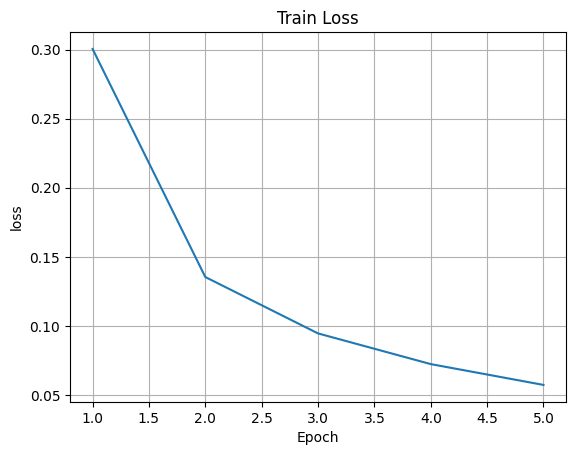

In [51]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr=LR)
    loss_history = Train(model, train_DL, criterion, optimizer,EPOCH)

    torch.save(model, save_model_path)

    plt.plot(range(1,EPOCH+1),loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('loss')
    plt.title("Train Loss")
    plt.grid()

In [38]:
load_model = torch.load(save_model_path, map_location=DEVICE)
# model.state.dict()

<ipython-input-38-9eccb9c77a66>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  load_model = torch.load(save_model_path, map_location=DEVICE)


In [39]:
Test(load_model, test_DL)
print(count_params(load_model))

Test accuracy: 9737/10000 (97.4 %)
79510


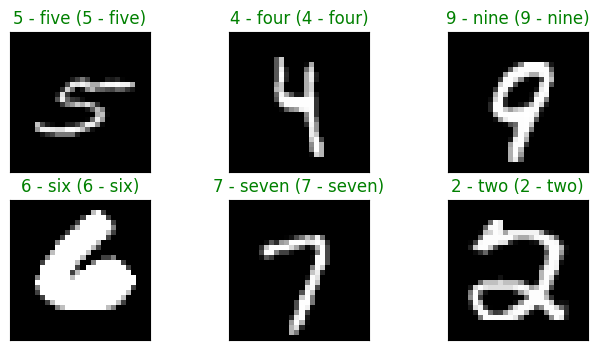

In [40]:
Test_plot(load_model, test_DL)